ST 3011 - Statistical Programming

Group Project: Youth Unemployment Patterns in Sri Laka

Group 6

In [362]:
import pandas as pd
import numpy as np

**Data Preprocessing**

In [363]:
df = pd.read_csv("LFS-2023-25-Percent-Data-Without-Computer.csv")
df.head()

,YEAR,MONTH,SECTOR,DISTRICT,PSU,HUNIT,HHOLD,SERNO,RSHIP,SEX,...,Q63_A_22,Q63_A_3,Q63_A_42,Q63_A_5,Q63_B_22,Q63_B_3,Q63_B_42,Q63_B_5,Q64,Annual_Factor
0,2023,1,1,11,1,2,1,1,1,2,...,,,,,,,,,2,1309.608564
1,2023,1,1,11,1,2,1,2,2,1,...,,,,,,,,,3,1309.608564
2,2023,1,1,11,1,6,1,1,1,1,...,,,,,,,,,2,1309.608564
3,2023,1,1,11,1,6,1,2,2,2,...,,,,,,,,,2,1309.608564
4,2023,1,1,11,1,6,1,3,3,1,...,,,,,,,,,10,1309.608564


In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18937 entries, 0 to 18936
Columns: 128 entries, YEAR to Annual_Factor
dtypes: float64(1), int64(21), object(106)
memory usage: 18.5+ MB


In [365]:
df.shape

(18937, 128)

Select Required Variables

In [366]:
required_cols = [
    'MONTH',
    'SECTOR', 'DISTRICT', 'PSU', 'HUNIT', 'HHOLD', 'SERNO',
    'SEX', 'BYEAR', 'BMONTH', 'AGE',
    'EDU', 'CUEDU', 'P21',
    'Q2', 'Q4', 'Q6_A',
    'Q47', 'Q48', 'Q50', 'Q51', 'Q52'
]

df = df[required_cols].copy()

In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18937 entries, 0 to 18936
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   MONTH     18937 non-null  int64 
 1   SECTOR    18937 non-null  int64 
 2   DISTRICT  18937 non-null  int64 
 3   PSU       18937 non-null  int64 
 4   HUNIT     18937 non-null  int64 
 5   HHOLD     18937 non-null  int64 
 6   SERNO     18937 non-null  int64 
 7   SEX       18937 non-null  int64 
 8   BYEAR     18937 non-null  int64 
 9   BMONTH    18937 non-null  object
 10  AGE       18937 non-null  int64 
 11  EDU       18937 non-null  object
 12  CUEDU     18937 non-null  object
 13  P21       18937 non-null  object
 14  Q2        18937 non-null  object
 15  Q4        18937 non-null  object
 16  Q6_A      18937 non-null  object
 17  Q47       18937 non-null  object
 18  Q48       18937 non-null  object
 19  Q50       18937 non-null  object
 20  Q51       18937 non-null  object
 21  Q52       18

In [368]:
#Convert questionnaire variables to numeric
survey_cols = [
    'BMONTH', 'EDU', 'CUEDU', 'P21',
    'Q2', 'Q4', 'Q6_A',
    'Q47', 'Q48', 'Q50', 'Q51', 'Q52'
]

for col in survey_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18937 entries, 0 to 18936
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MONTH     18937 non-null  int64  
 1   SECTOR    18937 non-null  int64  
 2   DISTRICT  18937 non-null  int64  
 3   PSU       18937 non-null  int64  
 4   HUNIT     18937 non-null  int64  
 5   HHOLD     18937 non-null  int64  
 6   SERNO     18937 non-null  int64  
 7   SEX       18937 non-null  int64  
 8   BYEAR     18937 non-null  int64  
 9   BMONTH    18732 non-null  float64
 10  AGE       18937 non-null  int64  
 11  EDU       17918 non-null  float64
 12  CUEDU     17918 non-null  float64
 13  P21       15230 non-null  float64
 14  Q2        15230 non-null  float64
 15  Q4        8466 non-null   float64
 16  Q6_A      8177 non-null   float64
 17  Q47       8177 non-null   float64
 18  Q48       500 non-null    float64
 19  Q50       208 non-null    float64
 20  Q51       500 non-null    fl

Define youth population (Age 15–29)


In [370]:
df_youth = df[(df['AGE'] >= 15) & (df['AGE'] <= 29)].copy()

In [371]:
df_youth.shape

(3949, 22)

Create employment status variable

In [372]:
def derive_employment_status(row):
    # Employed
    if (row['Q2'] == 1) or (row['Q4'] == 1) or (row['Q6_A'] == 1):
        return 'Employed'

    # Unemployed
    elif (row['Q48'] == 1) and (row['Q51'] == 1):
        return 'Unemployed'

    # Not in Labour Force
    else:
        return 'Not in Labour Force'


In [373]:
df_youth['employment_status'] = df_youth.apply(
    derive_employment_status, axis=1
)

In [374]:
df_youth['employment_status'].value_counts()

employment_status
Not in Labour Force    2521
Employed               1239
Unemployed              189
Name: count, dtype: int64

Recoding Variables

In [375]:
#Recode SECTOR
df_youth['SECTOR'] = df_youth['SECTOR'].map({
    1: 'Urban',
    2: 'Rural',
    3: 'Estate'
}).astype('category')

In [376]:
#Recode District
district_labels = {
    11: 'Colombo', 12: 'Gampaha', 13: 'Kalutara',
    21: 'Kandy', 22: 'Matale', 23: 'Nuwara Eliya',
    31: 'Galle', 32: 'Matara', 33: 'Hambantota',
    41: 'Jaffna', 42: 'Mannar', 43: 'Vavuniya',
    44: 'Mullaitivu', 45: 'Kilinochchi',
    51: 'Batticaloa', 52: 'Ampara', 53: 'Trincomalee',
    61: 'Kurunegala', 62: 'Puttalam',
    71: 'Anuradhapura', 72: 'Polonnaruwa',
    81: 'Badulla', 82: 'Monaragala',
    91: 'Ratnapura', 92: 'Kegalle'
}

df_youth['DISTRICT'] = df_youth['DISTRICT'].map(district_labels).astype('category')

In [377]:
#Recode SEX
df_youth['SEX'] = df_youth['SEX'].map({
    1: 'Male',
    2: 'Female'
}).astype('category')

In [378]:
#Recode EDU
edu_labels = {
    0.0: 'Studying / Studied Grade 1',
    1.0: 'Passed Grade 1',
    2.0: 'Passed Grade 2',
    3.0: 'Passed Grade 3',
    4.0: 'Passed Grade 4',
    5.0: 'Passed Grade 5' ,
    6.0: 'Passed Grade 6',
    7.0: 'Passed Grade 7',
    8.0: 'Passed Grade 8',
    9.0: 'Passed Grade 9',
    10.0: 'Passed Grade 10',
    11.0: 'Passed G.C.E.(O/L)/ N.C.G.E. ',
    12.0: 'Passed Grade 12',
    13.0:' Passed G.C.E.(A/L)/ H.N.C.E. ',
    14.0: 'Passed G.A.Q./G.S.Q.' ,
    15.0: 'Degree ',
    16.0: 'Post Graduate Degree/ Diploma ',
    17.0: 'Special educational Institutions',
    19.0: 'No Schooling'
}

df_youth['EDU'] = df_youth['EDU'].map(edu_labels).astype('category')

In [379]:
#Recode CUEDU
cuedu_labels = {
    1: 'School',
    2: 'University',
    3: 'Other Educational Institution',
    4: 'Vocational / Technical Institution',
    5: 'Does not attend'
}

df_youth['CUEDU'] = df_youth['CUEDU'].map(cuedu_labels).astype('category')

In [380]:
#Recode P21
df_youth['P21'] = df_youth['P21'].map({
    1: 'Currently studying/training',
    2: 'Not studying'
}).astype('category')

In [381]:
df_youth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3949 entries, 1 to 18930
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   MONTH              3949 non-null   int64   
 1   SECTOR             3949 non-null   category
 2   DISTRICT           3949 non-null   category
 3   PSU                3949 non-null   int64   
 4   HUNIT              3949 non-null   int64   
 5   HHOLD              3949 non-null   int64   
 6   SERNO              3949 non-null   int64   
 7   SEX                3949 non-null   category
 8   BYEAR              3949 non-null   int64   
 9   BMONTH             3926 non-null   float64 
 10  AGE                3949 non-null   int64   
 11  EDU                3949 non-null   category
 12  CUEDU              3949 non-null   category
 13  P21                3949 non-null   category
 14  Q2                 3949 non-null   float64 
 15  Q4                 2812 non-null   float64 
 16  Q6_A      

In [382]:
df_youth.head()

,MONTH,SECTOR,DISTRICT,PSU,HUNIT,HHOLD,SERNO,SEX,BYEAR,BMONTH,...,P21,Q2,Q4,Q6_A,Q47,Q48,Q50,Q51,Q52,employment_status
1,1,Urban,Colombo,1,2,1,2,Male,1993,4.0,...,Not studying,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Employed
4,1,Urban,Colombo,1,6,1,3,Male,2003,3.0,...,Not studying,2.0,2.0,2.0,2.0,NaN,NaN,NaN,4.0,Not in Labour Force
5,1,Urban,Colombo,1,6,1,4,Male,2006,3.0,...,Currently studying/training,2.0,2.0,2.0,2.0,NaN,NaN,NaN,1.0,Not in Labour Force
9,1,Urban,Colombo,1,10,1,2,Male,2007,7.0,...,Currently studying/training,2.0,2.0,2.0,2.0,NaN,NaN,NaN,1.0,Not in Labour Force
15,1,Urban,Colombo,2,8,1,2,Female,1999,11.0,...,Not studying,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Employed


In [383]:
df_youth['employment_status'] = df_youth['employment_status'].astype('category')

df_youth['employment_status'].cat.categories

Index(['Employed', 'Not in Labour Force', 'Unemployed'], dtype='object')

In [384]:
df_youth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3949 entries, 1 to 18930
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   MONTH              3949 non-null   int64   
 1   SECTOR             3949 non-null   category
 2   DISTRICT           3949 non-null   category
 3   PSU                3949 non-null   int64   
 4   HUNIT              3949 non-null   int64   
 5   HHOLD              3949 non-null   int64   
 6   SERNO              3949 non-null   int64   
 7   SEX                3949 non-null   category
 8   BYEAR              3949 non-null   int64   
 9   BMONTH             3926 non-null   float64 
 10  AGE                3949 non-null   int64   
 11  EDU                3949 non-null   category
 12  CUEDU              3949 non-null   category
 13  P21                3949 non-null   category
 14  Q2                 3949 non-null   float64 
 15  Q4                 2812 non-null   float64 
 16  Q6_A      

Checking Missing Values

In [385]:
df_youth.isnull().sum()

MONTH                   0
SECTOR                  0
DISTRICT                0
PSU                     0
HUNIT                   0
HHOLD                   0
SERNO                   0
SEX                     0
BYEAR                   0
BMONTH                 23
AGE                     0
EDU                     0
CUEDU                   0
P21                     0
Q2                      0
Q4                   1137
Q6_A                 1165
Q47                  1165
Q48                  3600
Q50                  3812
Q51                  3600
Q52                  1500
employment_status       0
dtype: int64

Check Duplicate Records

In [386]:
df_youth.duplicated().sum()

np.int64(0)

Youth population dataset (3 categories - Employed, Unemployed, Not in Labour Force)

In [387]:
df_youth_full = df_youth.copy()

df_youth_full['employment_status'].value_counts()

employment_status
Not in Labour Force    2521
Employed               1239
Unemployed              189
Name: count, dtype: int64

Youth Labour force dataset (Employed and Unemployed)

In [388]:
df_lf = df_youth_full[
    df_youth_full['employment_status'].isin(['Employed', 'Unemployed'])
].copy()

df_lf['employment_status'].value_counts()

employment_status
Employed               1239
Unemployed              189
Not in Labour Force       0
Name: count, dtype: int64

In [389]:
df_youth_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3949 entries, 1 to 18930
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   MONTH              3949 non-null   int64   
 1   SECTOR             3949 non-null   category
 2   DISTRICT           3949 non-null   category
 3   PSU                3949 non-null   int64   
 4   HUNIT              3949 non-null   int64   
 5   HHOLD              3949 non-null   int64   
 6   SERNO              3949 non-null   int64   
 7   SEX                3949 non-null   category
 8   BYEAR              3949 non-null   int64   
 9   BMONTH             3926 non-null   float64 
 10  AGE                3949 non-null   int64   
 11  EDU                3949 non-null   category
 12  CUEDU              3949 non-null   category
 13  P21                3949 non-null   category
 14  Q2                 3949 non-null   float64 
 15  Q4                 2812 non-null   float64 
 16  Q6_A      

In [390]:
df_lf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 1 to 18900
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   MONTH              1428 non-null   int64   
 1   SECTOR             1428 non-null   category
 2   DISTRICT           1428 non-null   category
 3   PSU                1428 non-null   int64   
 4   HUNIT              1428 non-null   int64   
 5   HHOLD              1428 non-null   int64   
 6   SERNO              1428 non-null   int64   
 7   SEX                1428 non-null   category
 8   BYEAR              1428 non-null   int64   
 9   BMONTH             1418 non-null   float64 
 10  AGE                1428 non-null   int64   
 11  EDU                1428 non-null   category
 12  CUEDU              1428 non-null   category
 13  P21                1428 non-null   category
 14  Q2                 1428 non-null   float64 
 15  Q4                 291 non-null    float64 
 16  Q6_A      

In [391]:
#Export youth population dataset
df_youth_full.to_csv("youth_population.csv", index=False)

In [392]:
#Export labour force dataset
df_lf.to_csv("youth_labour_force.csv", index=False)

**Objective 1**

**Descriptive Analysis of Youth Unemployment**

Target Variable

In [393]:
import matplotlib.pyplot as plt
import seaborn as sns

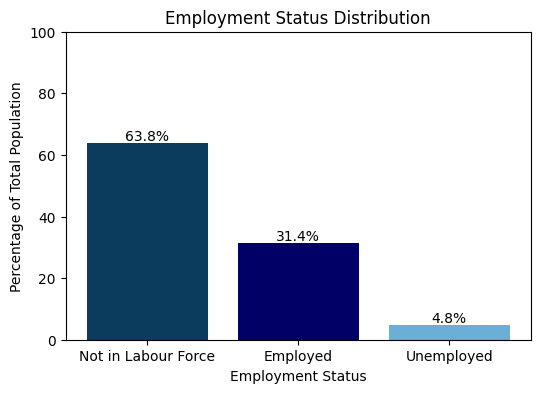

In [394]:
emp_counts = df_youth_full['employment_status'].value_counts()

# Convert to percentage of total population (sum = 100%)
emp_pct = emp_counts / emp_counts.sum() * 100

# Plot bar chart
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(emp_pct.index, emp_pct.values, color=[ '#0B3C5D', '#000066', '#6BAED6'])

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center')

# Labels and title
plt.ylabel("Percentage of Total Population")
plt.xlabel("Employment Status")
plt.title("Employment Status Distribution")
plt.ylim(0, 100)  # total scale = 100%
plt.show()

In [395]:
unemp_youth = df_lf[df_lf['employment_status'] == 'Unemployed']

In [396]:
def to_percent(series):
    return series / series.sum() * 100

In [397]:
def add_percentage_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge')

Age

In [398]:
age_unemp = unemp_youth['AGE'].value_counts().sort_index()
age_unemp_pct = to_percent(age_unemp)
print(age_unemp_pct)

AGE
16     0.529101
17     1.058201
18     3.703704
19     4.761905
20     8.465608
21    12.169312
22    11.640212
23     6.878307
24    11.640212
25    11.111111
26     6.878307
27     8.465608
28     6.349206
29     6.349206
Name: count, dtype: float64


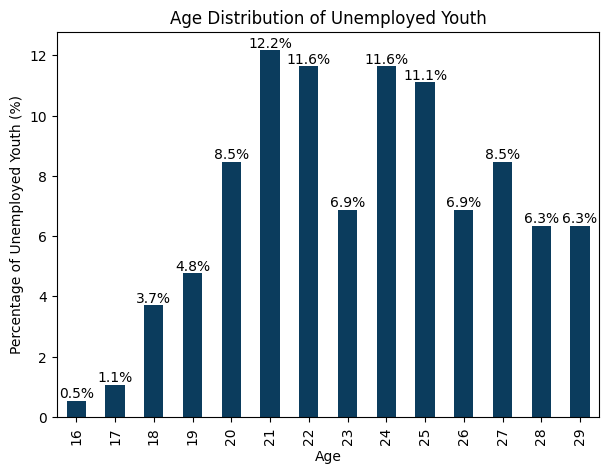

In [399]:
ax = age_unemp_pct.plot(
    kind='bar',
    figsize=(7,5),
    color='#0B3C5D'
)

ax.set_xlabel("Age")
ax.set_ylabel("Percentage of Unemployed Youth (%)")
ax.set_title("Age Distribution of Unemployed Youth")

add_percentage_labels(ax)
plt.show()

Sex

In [400]:
sex_unemp = unemp_youth['SEX'].value_counts()
sex_unemp_pct = sex_unemp / sex_unemp.sum() * 100

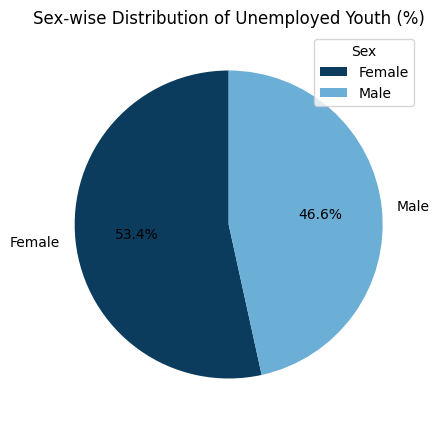

In [401]:
plt.figure(figsize=(5,5))
plt.pie(
    sex_unemp_pct,
    labels=sex_unemp_pct.index,
    autopct='%.1f%%',
    startangle=90,
    colors=['#0B3C5D', '#6BAED6']
)

plt.legend(
    sex_unemp_pct.index,
    title="Sex",
    loc="best"
)

plt.title("Sex-wise Distribution of Unemployed Youth (%)")
plt.show()

Sector

In [402]:
sector_unemp = unemp_youth['SECTOR'].value_counts()
sector_unemp_pct = to_percent(sector_unemp)

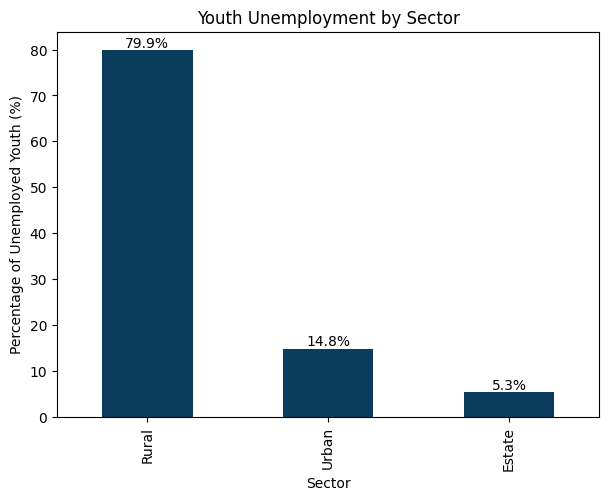

In [403]:
ax = sector_unemp_pct.plot(
    kind='bar',
    color='#0B3C5D',
    figsize=(7,5)
)

ax.set_xlabel("Sector")
ax.set_ylabel("Percentage of Unemployed Youth (%)")
ax.set_title("Youth Unemployment by Sector")

add_percentage_labels(ax)
plt.show()

District

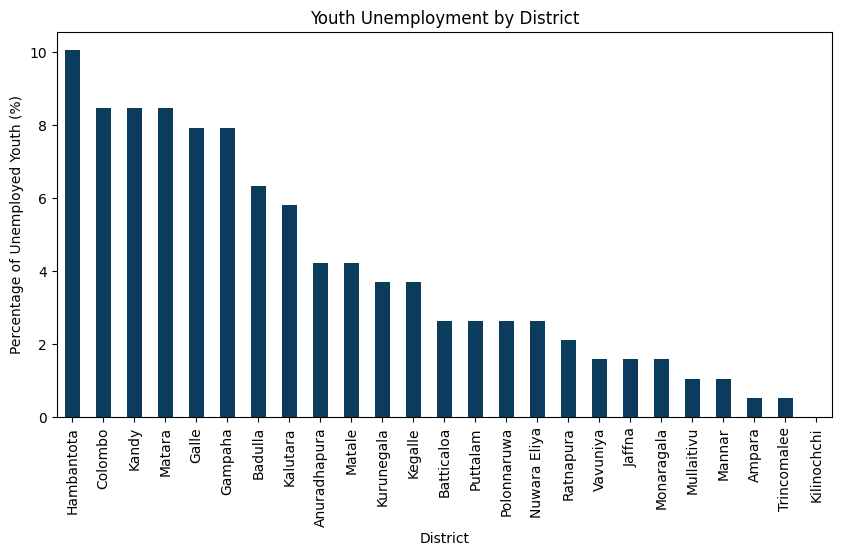

In [404]:
district_unemp = unemp_youth['DISTRICT'].value_counts()
district_unemp_pct = to_percent(district_unemp)

ax = district_unemp_pct.plot(
    kind='bar',
    figsize=(10,5),
    color='#0B3C5D'
)

ax.set_xlabel("District")
ax.set_ylabel("Percentage of Unemployed Youth (%)")
ax.set_title("Youth Unemployment by District")

plt.show()

**Objective 2**

**Educational Attainment and Youth Unemployment**

Group Educational Attainment (EDU)

In [405]:
def recode_edu(edu):
    edu = str(edu).strip()

    # Primary or Below
    if edu in [
        'No Schooling',
        'Studying / Studied Grade 1',
        'Passed Grade 1',
        'Passed Grade 2',
        'Passed Grade 3',
        'Passed Grade 4',
        'Passed Grade 5'
    ]:
        return 'Grade 5 or Below'

    # Junior Secondary
    elif edu in [
        'Passed Grade 6',
        'Passed Grade 7',
        'Passed Grade 8',
        'Passed Grade 9',
        'Passed Grade 10'
    ]:
        return 'Grade 6-10'

    # Secondary (O/L)
    elif edu in [
        'Passed G.C.E.(O/L)/ N.C.G.E.'
    ]:
        return 'G.C.E.(O/L)'

    # Senior Secondary (A/L)
    elif edu in [
        'Passed Grade 12',
        'Passed G.C.E.(A/L)/ H.N.C.E.'
    ]:
        return 'G.C.E.(A/L)'

    else:
        return 'Degree / Education institue'

In [406]:
df_lf['EDU_group'] = df_lf['EDU'].apply(recode_edu)
df_lf[['EDU', 'EDU_group']].head(20)

,EDU,EDU_group
1,Passed G.C.E.(A/L)/ H.N.C.E.,G.C.E.(A/L)
15,Degree,Degree / Education institue
20,Passed G.C.E.(A/L)/ H.N.C.E.,G.C.E.(A/L)
29,Passed G.C.E.(A/L)/ H.N.C.E.,G.C.E.(A/L)
48,Passed Grade 10,Grade 6-10
49,Passed Grade 9,Grade 6-10
55,Passed Grade 10,Grade 6-10
56,Passed Grade 10,Grade 6-10
76,Passed Grade 10,Grade 6-10
83,Passed Grade 10,Grade 6-10


Educational Attainment (EDU)

In [407]:
edu_group_table = pd.crosstab(df_lf['EDU_group'], df_lf['employment_status'])

edu_order = [
    'Grade 5 or Below',
    'Grade 6-10',
    'G.C.E.(O/L)',
    'G.C.E.(A/L)',
    'Degree / Education institue'
]

edu_group_table = edu_group_table.reindex(edu_order)
edu_group_table

employment_status,Employed,Unemployed
EDU_group,,
Grade 5 or Below,16,1
Grade 6-10,501,46
G.C.E.(O/L),174,20
G.C.E.(A/L),456,96
Degree / Education institue,92,26


In [408]:
edu_unemp = edu_group_table['Unemployed']
edu_unemp

EDU_group
Grade 5 or Below                1
Grade 6-10                     46
G.C.E.(O/L)                    20
G.C.E.(A/L)                    96
Degree / Education institue    26
Name: Unemployed, dtype: int64

In [409]:
unemp_edu_rate = (edu_unemp / edu_unemp.sum()) * 100
unemp_edu_rate = unemp_edu_rate.round(1)
unemp_edu_rate

EDU_group
Grade 5 or Below                0.5
Grade 6-10                     24.3
G.C.E.(O/L)                    10.6
G.C.E.(A/L)                    50.8
Degree / Education institue    13.8
Name: Unemployed, dtype: float64

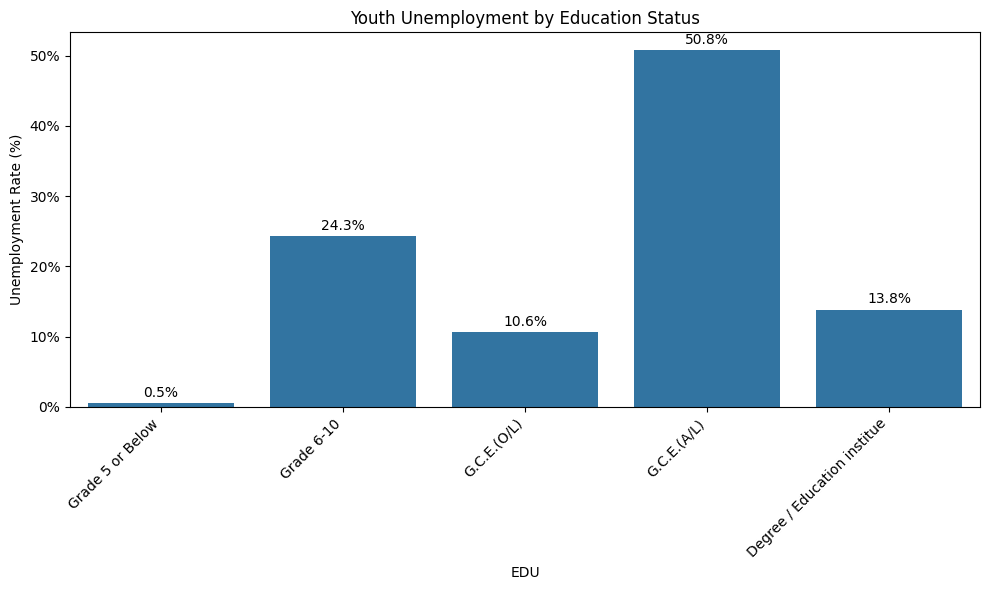

In [410]:
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
ax = sns.barplot(x=unemp_edu_rate.index, y=unemp_edu_rate.values)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("EDU")
plt.title("Youth Unemployment by Education Status")

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter())

# Add percentage labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%',
            ha='center', va='bottom')


plt.tight_layout()
plt.show()

Current Educational Attainment (CUEDU)

In [411]:
cuedu_df = df_lf[['CUEDU', 'employment_status']]
cuedu_df.head()

,CUEDU,employment_status
1,Does not attend,Employed
15,Other Educational Institution,Employed
20,Does not attend,Employed
29,Does not attend,Employed
48,Does not attend,Employed


In [412]:
cuedu_table = pd.crosstab(cuedu_df['CUEDU'], cuedu_df['employment_status'])
cuedu_table

employment_status,Employed,Unemployed
CUEDU,,
Does not attend,1140,158
Other Educational Institution,40,19
School,13,0
University,19,3
Vocational / Technical Institution,27,9


In [413]:
cuedu_unemp = cuedu_table['Unemployed']

unemp_cuedu_rate = (cuedu_unemp /cuedu_unemp.sum()) * 100
unemp_cuedu_rate = unemp_cuedu_rate.round(1)  # 1 decimal place
unemp_cuedu_rate

CUEDU
Does not attend                       83.6
Other Educational Institution         10.1
School                                 0.0
University                             1.6
Vocational / Technical Institution     4.8
Name: Unemployed, dtype: float64

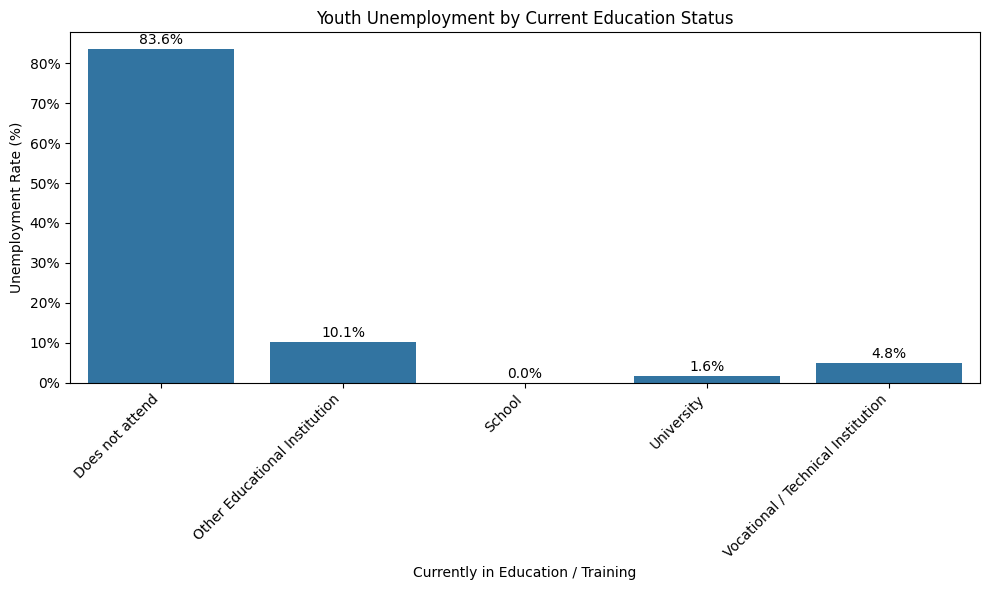

In [414]:
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=unemp_cuedu_rate.index, y=unemp_cuedu_rate.values
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Currently in Education / Training")
plt.title("Youth Unemployment by Current Education Status")

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter())

# Add percentage labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

Gender Differences by Educational Levels

In [415]:
edu_gender_table = pd.crosstab(index = [df_lf['EDU_group'], df_lf['SEX']], columns=df_lf['employment_status'])
edu_gender_table

employment_status                   Employed  Unemployed
EDU_group                   SEX                         
Degree / Education institue Female        57          18
                            Male          35           8
G.C.E.(A/L)                 Female       210          59
                            Male         246          37
G.C.E.(O/L)                 Female        56          12
                            Male         118           8
Grade 5 or Below            Female         5           0
                            Male          11           1
Grade 6-10                  Female       107          12
                            Male         394          34

In [416]:
edu_gender_unemp = edu_gender_table['Unemployed'].reset_index()
edu_gender_unemp

,EDU_group,SEX,Unemployed
0,Degree / Education institue,Female,18
1,Degree / Education institue,Male,8
2,G.C.E.(A/L),Female,59
3,G.C.E.(A/L),Male,37
4,G.C.E.(O/L),Female,12
5,G.C.E.(O/L),Male,8
6,Grade 5 or Below,Female,0
7,Grade 5 or Below,Male,1
8,Grade 6-10,Female,12
9,Grade 6-10,Male,34


In [417]:
edu_gender_unemp_table = edu_gender_unemp.pivot(index='EDU_group', columns='SEX', values='Unemployed')
edu_gender_unemp_table

SEX,Female,Male
EDU_group,,
Degree / Education institue,18,8
G.C.E.(A/L),59,37
G.C.E.(O/L),12,8
Grade 5 or Below,0,1
Grade 6-10,12,34


In [418]:
edu_gender_percent = edu_gender_unemp_table.div(edu_gender_unemp_table.sum(axis=1), axis=0) * 100
edu_gender_percent

SEX,Female,Male
EDU_group,,
Degree / Education institue,69.230769,30.769231
G.C.E.(A/L),61.458333,38.541667
G.C.E.(O/L),60.000000,40.000000
Grade 5 or Below,0.000000,100.000000
Grade 6-10,26.086957,73.913043


In [419]:
edu_order = [
    'Grade 5 or Below',
    'Grade 6-10',
    'G.C.E.(O/L)',
    'G.C.E.(A/L)',
    'Degree / Education institue'
]

edu_gender_percent = edu_gender_percent.reindex(edu_order)
edu_gender_percent = edu_gender_percent.round(1)
edu_gender_percent

SEX,Female,Male
EDU_group,,
Grade 5 or Below,0.0,100.0
Grade 6-10,26.1,73.9
G.C.E.(O/L),60.0,40.0
G.C.E.(A/L),61.5,38.5
Degree / Education institue,69.2,30.8


In [420]:
plot_edu_gender = edu_gender_percent.reset_index().melt(
        id_vars='EDU_group',
    value_vars=['Male', 'Female'],
    var_name='Gender',
    value_name='Percentage'
)
plot_edu_gender

,EDU_group,Gender,Percentage
0,Grade 5 or Below,Male,100.0
1,Grade 6-10,Male,73.9
2,G.C.E.(O/L),Male,40.0
3,G.C.E.(A/L),Male,38.5
4,Degree / Education institue,Male,30.8
5,Grade 5 or Below,Female,0.0
6,Grade 6-10,Female,26.1
7,G.C.E.(O/L),Female,60.0
8,G.C.E.(A/L),Female,61.5
9,Degree / Education institue,Female,69.2


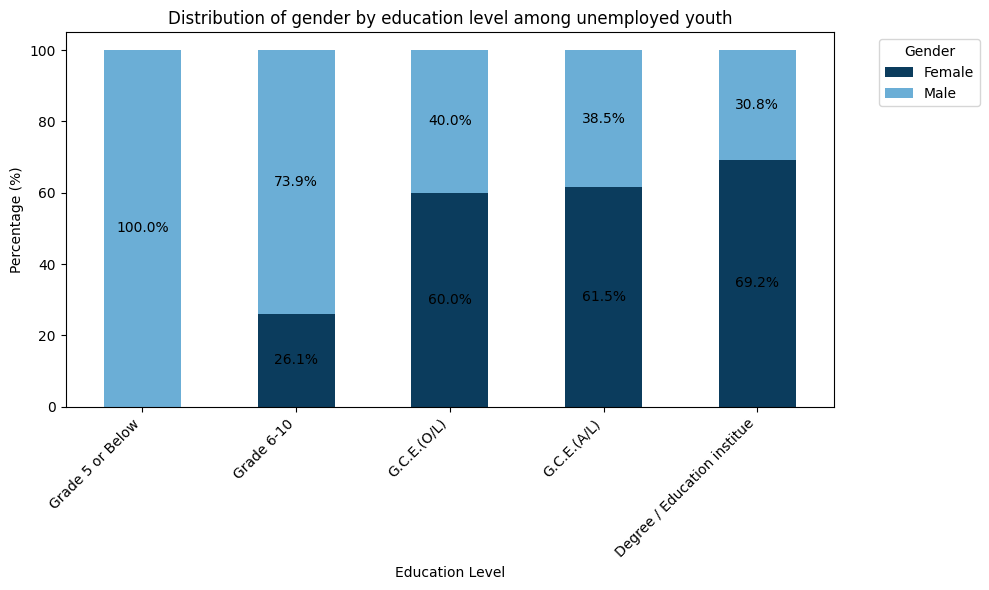

In [421]:
import matplotlib.pyplot as plt
import pandas as pd

# Pivot the data
stack_df = plot_edu_gender.pivot(index='EDU_group', columns='Gender', values='Percentage')

# Reorder rows according to your desired order
stack_df = stack_df.reindex(edu_order)

# Plot stacked bar chart
ax = stack_df.plot(kind='bar', stacked=True, figsize=(10,6), color=['#0B3C5D', '#6BAED6'])

# Add percentages on top of each segment
for i, edu in enumerate(stack_df.index):
    bottom = 0
    for status in stack_df.columns:
        value = stack_df.loc[edu, status]
        if not pd.isna(value) and value > 0:
            ax.text(i, bottom + value/2, f'{value:.1f}%', ha='center', va='center', color='black', fontsize=10)
            bottom += value

plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.xlabel("Education Level")
plt.title("Distribution of gender by education level among unemployed youth")
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [422]:
edu_gender_unemp_table

SEX,Female,Male
EDU_group,,
Degree / Education institue,18,8
G.C.E.(A/L),59,37
G.C.E.(O/L),12,8
Grade 5 or Below,0,1
Grade 6-10,12,34


In [423]:
# Create the combined row
combined_row = (
    edu_gender_unemp_table.loc["Grade 5 or Below"] +
    edu_gender_unemp_table.loc["Grade 6-10"]
)

# Drop the old rows
edu_gender_unemp_table = edu_gender_unemp_table.drop(
    ["Grade 5 or Below", "Grade 6-10"]
)

# Add the new combined row
edu_gender_unemp_table.loc["Grade 10 or Below"] = combined_row

print(edu_gender_unemp_table)

SEX                          Female  Male
EDU_group                                
Degree / Education institue      18     8
G.C.E.(A/L)                      59    37
G.C.E.(O/L)                      12     8
Grade 10 or Below                12    35


In [424]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(edu_gender_unemp_table)

print('Degree of freedom: ', dof)
print("Chi-square:", chi2)
print("p-value:", p)

Degree of freedom:  3
Chi-square: 20.14426450994629
p-value: 0.00015844856721700787


Gender Difference by Current Education

In [425]:
cuedu_gender_table = pd.crosstab(index = [df_lf['CUEDU'], df_lf['SEX']], columns=df_lf['employment_status'])
cuedu_gender_table

employment_status                          Employed  Unemployed
CUEDU                              SEX                         
Does not attend                    Female       394          83
                                   Male         746          75
Other Educational Institution      Female        17          13
                                   Male          23           6
School                             Female         5           0
                                   Male           8           0
University                         Female         9           2
                                   Male          10           1
Vocational / Technical Institution Female        10           3
                                   Male          17           6

In [426]:
cuedu_gender_unemp = cuedu_gender_table['Unemployed'].reset_index()
cuedu_gender_unemp

,CUEDU,SEX,Unemployed
0,Does not attend,Female,83
1,Does not attend,Male,75
2,Other Educational Institution,Female,13
3,Other Educational Institution,Male,6
4,School,Female,0
5,School,Male,0
6,University,Female,2
7,University,Male,1
8,Vocational / Technical Institution,Female,3
9,Vocational / Technical Institution,Male,6


In [427]:
cuedu_gender_unemp_table = cuedu_gender_unemp.pivot(index='CUEDU', columns='SEX', values='Unemployed')
cuedu_gender_unemp_table

SEX,Female,Male
CUEDU,,
Does not attend,83,75
Other Educational Institution,13,6
School,0,0
University,2,1
Vocational / Technical Institution,3,6


In [428]:
cuedu_gender_percent = cuedu_gender_unemp_table.div(cuedu_gender_unemp_table.sum(axis=1), axis=0) * 100
cuedu_gender_percent

SEX,Female,Male
CUEDU,,
Does not attend,52.531646,47.468354
Other Educational Institution,68.421053,31.578947
School,NaN,NaN
University,66.666667,33.333333
Vocational / Technical Institution,33.333333,66.666667


In [429]:
cuedu_gender_percent = cuedu_gender_percent.round(1)
cuedu_gender_percent

SEX,Female,Male
CUEDU,,
Does not attend,52.5,47.5
Other Educational Institution,68.4,31.6
School,NaN,NaN
University,66.7,33.3
Vocational / Technical Institution,33.3,66.7


In [430]:
plot_cuedu_gender = cuedu_gender_percent.reset_index().melt(
        id_vars='CUEDU',
    value_vars=['Male', 'Female'],
    var_name='Gender',
    value_name='Percentage'
)
plot_cuedu_gender

,CUEDU,Gender,Percentage
0,Does not attend,Male,47.5
1,Other Educational Institution,Male,31.6
2,School,Male,NaN
3,University,Male,33.3
4,Vocational / Technical Institution,Male,66.7
5,Does not attend,Female,52.5
6,Other Educational Institution,Female,68.4
7,School,Female,NaN
8,University,Female,66.7
9,Vocational / Technical Institution,Female,33.3


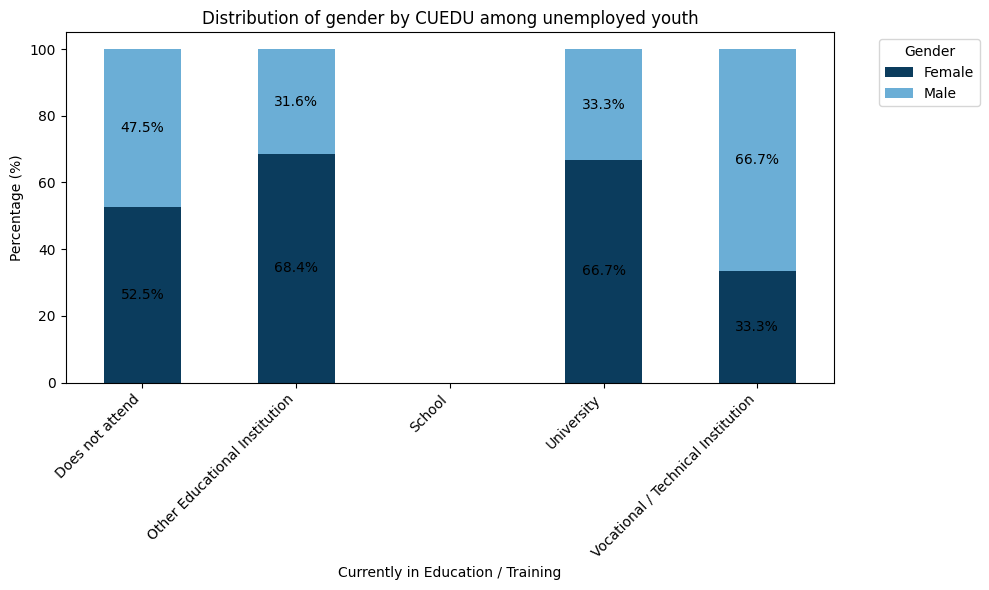

In [431]:
import matplotlib.pyplot as plt
import pandas as pd

# Pivot the data
stack_df = plot_cuedu_gender.pivot(index='CUEDU', columns='Gender', values='Percentage')

# Plot stacked bar chart
ax = stack_df.plot(kind='bar', stacked=True, figsize=(10,6), color=['#0B3C5D', '#6BAED6'])

# Add percentages on top of each segment
for i, edu in enumerate(stack_df.index):
    bottom = 0
    for status in stack_df.columns:
        value = stack_df.loc[edu, status]
        if not pd.isna(value) and value > 0:
            ax.text(i, bottom + value/2, f'{value:.1f}%', ha='center', va='center', color='black', fontsize=10)
            bottom += value

plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.xlabel("Currently in Education / Training")
plt.title("Distribution of gender by CUEDU among unemployed youth")
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [432]:
from scipy.stats import chi2_contingency

# Remove rows where both Female and Male are 0
cuedu_gender_unemp_table = cuedu_gender_unemp_table.loc[
    ~((cuedu_gender_unemp_table['Female'] == 0) &
      (cuedu_gender_unemp_table['Male'] == 0))
]
print(cuedu_gender_unemp_table)

SEX                                 Female  Male
CUEDU                                           
Does not attend                         83    75
Other Educational Institution           13     6
University                               2     1
Vocational / Technical Institution       3     6


In [433]:
# Create the combined row
combined_row = (
    cuedu_gender_unemp_table.loc["University"] +
    cuedu_gender_unemp_table.loc["Vocational / Technical Institution"]
)

# Drop the old rows
cuedu_gender_unemp_table = cuedu_gender_unemp_table.drop(
    ["University", "Vocational / Technical Institution"]
)

# Add the new combined row
cuedu_gender_unemp_table.loc["Post-secondary"] = combined_row

print(cuedu_gender_unemp_table)

SEX                            Female  Male
CUEDU                                      
Does not attend                    83    75
Other Educational Institution      13     6
Post-secondary                      5     7


In [434]:
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(cuedu_gender_unemp_table)

print('Degree of freedom: ', dof)
print("Chi-square:", chi2)
print("p-value:", p_value)

Degree of freedom:  2
Chi-square: 2.434682852445804
p-value: 0.2960161023747797


**Objective 3**

**Gender Differences in Youth Unemployment Across Sectors and Districts**

Gender × Sector × Employment Status

In [435]:
sector_gender_table = (
    pd.crosstab(
        [df_lf['SECTOR'], df_lf['SEX']],
        df_lf['employment_status'],
        normalize='index'
    ) * 100
)

sector_gender_table.round(2)

employment_status  Employed  Unemployed
SECTOR SEX                             
Estate Female         78.57       21.43
       Male           90.70        9.30
Rural  Female         81.69       18.31
       Male           89.63       10.37
Urban  Female         79.27       20.73
       Male           92.41        7.59

In [436]:
# Extract unemployment rates (%) by sector and gender
sector_gender_unemp = sector_gender_table['Unemployed'].unstack()
sector_gender_unemp = sector_gender_unemp.round(2)

sector_gender_unemp

SEX,Female,Male
SECTOR,,
Estate,21.43,9.30
Rural,18.31,10.37
Urban,20.73,7.59


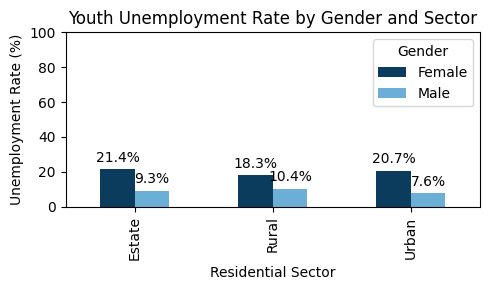

In [437]:
dark_blue = '#0B3C5D'   # Female
light_blue = '#6BAED6' # Male

import matplotlib.pyplot as plt

ax = sector_gender_unemp.plot(
    kind='bar',
    color=[dark_blue, light_blue],
    figsize=(5,3)
)

plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Residential Sector')
plt.title('Youth Unemployment Rate by Gender and Sector')
plt.ylim(0, 100)
plt.legend(title='Gender')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

In [438]:
### Statistical Test

from scipy.stats import chi2_contingency

sectors = df_lf['SECTOR'].unique()

print("Chi-square Tests: Gender × Sector")
for sector in sectors:
    subset = df_lf[df_lf['SECTOR'] == sector]

    # Contingency table: SEX x Employment Status
    table = pd.crosstab(subset['SEX'], subset['employment_status'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"Sector: {sector}")
    print("Chi-square statistic =", round(chi2, 2))
    print("Degrees of freedom =", dof)
    print("p-value =", round(p_value, 4))
    print("-"*40)

Chi-square Tests: Gender × Sector
Sector: Urban
Chi-square statistic = 7.2
Degrees of freedom = 1
p-value = 0.0073
----------------------------------------
Sector: Rural
Chi-square statistic = 13.78
Degrees of freedom = 1
p-value = 0.0002
----------------------------------------
Sector: Estate
Chi-square statistic = 1.18
Degrees of freedom = 1
p-value = 0.2773
----------------------------------------


In [439]:
## Checking Chi-square assumption (Expected counts ≥ 5) for  SECTOR = Estate

from scipy.stats import chi2_contingency

subset = df_lf[df_lf['SECTOR'] == 'Estate']
table = pd.crosstab(subset['SEX'], subset['employment_status'])

chi2, p, dof, expected = chi2_contingency(table)

expected

array([[24.05633803,  3.94366197],
       [36.94366197,  6.05633803]])

In [440]:
# 1 out of 4 cells is below 5
# That is 25% of cells
# Since small sample sizes

Gender × District × Employment Status

In [441]:
district_gender_table = (
    pd.crosstab(
        [df_lf['DISTRICT'], df_lf['SEX']],
        df_lf['employment_status'],
        normalize='index'
    ) * 100
).round(2)

# Sum unemployed percentages across gender for each district
district_unemp_sum = (
    district_gender_table['Unemployed']
    .groupby(level=0)
    .sum()
)

# Create a RANK variable
district_unemp_rank = (
    district_unemp_sum
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Attach the rank to the original table
district_gender_table = district_gender_table.copy()
district_gender_table['District_Unemployment_Rank'] = (
    district_gender_table.index.get_level_values(0)
    .map(district_unemp_rank)
)

district_order = district_unemp_rank.sort_values().index

# Sort and display
district_gender_table_sorted = (
    district_gender_table
    .loc[district_order]
)

district_gender_table_sorted

C:\Users\ijkan\AppData\Local\Temp\ipykernel_14496\4042440346.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0)


employment_status    Employed  Unemployed District_Unemployment_Rank
DISTRICT     SEX                                                    
Matara       Female     57.14       42.86                          1
             Male       72.97       27.03                          1
Badulla      Female     69.23       30.77                          2
             Male       65.22       34.78                          2
Hambantota   Female     51.61       48.39                          3
             Male       84.62       15.38                          3
Matale       Female     77.78       22.22                          4
             Male       80.95       19.05                          4
Galle        Female     72.41       27.59                          5
             Male       87.50       12.50                          5
Polonnaruwa  Female     75.00       25.00                          6
             Male       91.67        8.33                          6
Kandy        Female     82.69       17.31                          7
             Male       85.71       14.29                          7
Kalutara     Female     79.41       20.59                          8
             Male       89.74       10.26                          8
Anuradhapura Female     80.00       20.00                          9
             Male       89.74       10.26                          9
Kegalle      Female     81.82       18.18                         10
             Male       88.46       11.54                         10
Colombo      Female     82.69       17.31                         11
             Male       91.57        8.43                         11
Nuwara Eliya Female     78.95       21.05                         12
             Male       96.00        4.00                         12
Batticaloa   Female     80.00       20.00                         13
             Male       95.12        4.88                         13
Jaffna       Female     80.00       20.00                         14
             Male       96.97        3.03                         14
Gampaha      Female     87.04       12.96                         15
             Male       90.70        9.30                         15
Monaragala   Female     86.67       13.33                         16
             Male       95.00        5.00                         16
Kurunegala   Female     93.33        6.67                         17
             Male       88.64       11.36                         17
Puttalam     Female     92.86        7.14                         18
             Male       90.48        9.52                         18
Trincomalee  Female     85.71       14.29                         19
             Male      100.00        0.00                         19
Vavuniya     Female     93.33        6.67                         20
             Male       92.86        7.14                         20
Mullaitivu   Female     90.00       10.00                         21
             Male       96.43        3.57                         21
Ratnapura    Female     88.89       11.11                         22
             Male       97.62        2.38                         22
Ampara       Female     87.50       12.50                         23
             Male      100.00        0.00                         23
Mannar       Female    100.00        0.00                         24
             Male       93.33        6.67                         24
Kilinochchi  Female    100.00        0.00                         25
             Male      100.00        0.00                         25

C:\Users\ijkan\AppData\Local\Temp\ipykernel_14496\4223160359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_unemp_sum = district_gender_unemp['Unemployed'].groupby(level=0).sum()


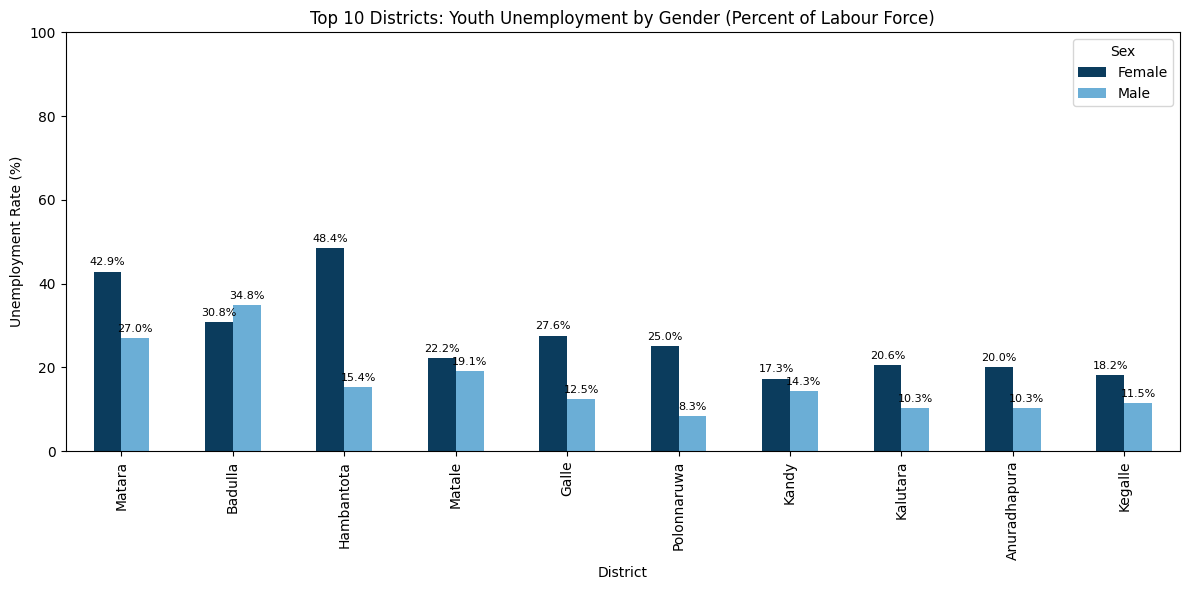

In [442]:
# Sum Unemployed percentage across gender for each district
district_gender_unemp = pd.crosstab(
    [df_lf['DISTRICT'], df_lf['SEX']],
    df_lf['employment_status'],
    normalize='index'
) * 100

district_gender_unemp = district_gender_unemp[['Unemployed']].round(2)

# Total unemployed per district (male + female)
district_unemp_sum = district_gender_unemp['Unemployed'].groupby(level=0).sum()

top10_districts = district_unemp_sum.sort_values(ascending=False).head(10).index
district_gender_top10 = district_gender_unemp.loc[top10_districts]
plot_df = district_gender_top10.reset_index().pivot(
    index='DISTRICT',
    columns='SEX',
    values='Unemployed'
)

# Ensure districts are in descending order
plot_df = plot_df.loc[top10_districts]


import matplotlib.pyplot as plt

dark_blue = '#0B3C5D'   # Female
light_blue = '#6BAED6'  # Male

ax = plot_df.plot(
    kind='bar',
    figsize=(12,6),
    color=[dark_blue, light_blue]
)

ax.set_ylabel("Unemployment Rate (%)")
ax.set_xlabel("District")
ax.set_title("Top 10 Districts: Youth Unemployment by Gender (Percent of Labour Force)")
ax.set_ylim(0, 100)
ax.legend(title='Sex')

# Add percentage labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=3)

plt.tight_layout()
plt.show()

In [443]:
# Gender × District Test (Top 10 Districts)
top10_districts = district_unemp_sum.sort_values(ascending=False).head(10).index

print("Chi-square Tests: Gender × District (Top 10)")

for district in top10_districts:
    subset = df_lf[df_lf['DISTRICT'] == district]

    table = pd.crosstab(subset['SEX'], subset['employment_status'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"District: {district}")
    print("Chi-square statistic =", round(chi2, 2))
    print("Degrees of freedom =", dof)
    print("p-value =", round(p_value, 4))
    print("-"*40)

Chi-square Tests: Gender × District (Top 10)
District: Matara
Chi-square statistic = 0.56
Degrees of freedom = 1
p-value = 0.4538
----------------------------------------
District: Badulla
Chi-square statistic = 0.0
Degrees of freedom = 1
p-value = 1.0
----------------------------------------
District: Hambantota
Chi-square statistic = 5.52
Degrees of freedom = 1
p-value = 0.0187
----------------------------------------
District: Matale
Chi-square statistic = 0.0
Degrees of freedom = 1
p-value = 1.0
----------------------------------------
District: Galle
Chi-square statistic = 2.04
Degrees of freedom = 1
p-value = 0.1528
----------------------------------------
District: Polonnaruwa
Chi-square statistic = 0.73
Degrees of freedom = 1
p-value = 0.3942
----------------------------------------
District: Kandy
Chi-square statistic = 0.02
Degrees of freedom = 1
p-value = 0.8862
----------------------------------------
District: Kalutara
Chi-square statistic = 0.82
Degrees of freedom = 1
p-v

In [444]:
## check expected frequencies for EACH district

from scipy.stats import chi2_contingency

print("Chi-square Assumption Check: District Level")
print("-" * 55)

for district in df_lf['DISTRICT'].unique():
    subset = df_lf[df_lf['DISTRICT'] == district]
    table = pd.crosstab(subset['SEX'], subset['employment_status'])

    # Skip if table is incomplete
    if table.shape != (2, 2):
        print(f"{district}: skipped (incomplete table)")
        continue

    chi2, p, dof, expected = chi2_contingency(table)

    min_expected = expected.min()

    if min_expected < 5:
        print(f"{district}: ⚠ min expected = {min_expected:.2f} (assumption violated)")
    else:
        print(f"{district}: ✓ min expected = {min_expected:.2f}")

Chi-square Assumption Check: District Level
-------------------------------------------------------
Colombo: ✓ min expected = 6.16
Gampaha: ✓ min expected = 5.79
Kalutara: ✓ min expected = 5.12
Kandy: ✓ min expected = 7.76
Matale: ⚠ min expected = 3.69 (assumption violated)
Nuwara Eliya: ⚠ min expected = 2.16 (assumption violated)
Galle: ✓ min expected = 5.12
Matara: ⚠ min expected = 4.39 (assumption violated)
Hambantota: ✓ min expected = 8.67
Jaffna: ⚠ min expected = 0.70 (assumption violated)
Mannar: ⚠ min expected = 0.38 (assumption violated)
Vavuniya: ⚠ min expected = 1.05 (assumption violated)
Mullaitivu: ⚠ min expected = 0.53 (assumption violated)
Kilinochchi: skipped (incomplete table)
Batticaloa: ⚠ min expected = 1.34 (assumption violated)
Ampara: ⚠ min expected = 0.38 (assumption violated)
Trincomalee: ⚠ min expected = 0.27 (assumption violated)
Kurunegala: ⚠ min expected = 2.84 (assumption violated)
Puttalam: ⚠ min expected = 1.25 (assumption violated)
Anuradhapura: ⚠ min exp

### Gender × Province × Unemployment

In [445]:
######### Create PROVINCE from DISTRICT

district_to_province = {
    # Western
    'Colombo': 'Western', 'Gampaha': 'Western', 'Kalutara': 'Western',

    # Central
    'Kandy': 'Central', 'Matale': 'Central', 'Nuwara Eliya': 'Central',

    # Southern
    'Galle': 'Southern', 'Matara': 'Southern', 'Hambantota': 'Southern',

    # Northern
    'Jaffna': 'Northern', 'Kilinochchi': 'Northern', 'Mannar': 'Northern',
    'Mullaitivu': 'Northern', 'Vavuniya': 'Northern',

    # Eastern
    'Trincomalee': 'Eastern', 'Batticaloa': 'Eastern', 'Ampara': 'Eastern',

    # North Western
    'Kurunegala': 'North Western', 'Puttalam': 'North Western',

    # North Central
    'Anuradhapura': 'North Central', 'Polonnaruwa': 'North Central',

    # Uva
    'Badulla': 'Uva', 'Monaragala': 'Uva',

    # Sabaragamuwa
    'Ratnapura': 'Sabaragamuwa', 'Kegalle': 'Sabaragamuwa'
}

df_lf['PROVINCE'] = df_lf['DISTRICT'].map(district_to_province)

# Check
df_lf['PROVINCE'].value_counts()

PROVINCE
Western          348
Southern         193
Northern         187
Central          184
North Western    130
Sabaragamuwa     117
Eastern          103
North Central     95
Uva               71
Name: count, dtype: int64

In [446]:
## Province × Gender unemployment table (percentages)

province_gender_unemp = (
    pd.crosstab(
        [df_lf['PROVINCE'], df_lf['SEX']],
        df_lf['employment_status'],
        normalize='index'
    ) * 100
)

province_gender_unemp = province_gender_unemp[['Unemployed']].round(2)
province_gender_unemp

employment_status     Unemployed
PROVINCE      SEX               
Central       Female       19.10
              Male         12.63
Eastern       Female       16.67
              Male          2.74
North Central Female       21.88
              Male          9.52
North Western Female        6.82
              Male         10.47
Northern      Female        8.00
              Male          4.38
Sabaragamuwa  Female       14.29
              Male          5.88
Southern      Female       39.19
              Male         17.65
Uva           Female       21.43
              Male         20.93
Western       Female       16.43
              Male          9.13

In [447]:
## Order provinces by total unemployment (Male + Female)

province_unemp_sum = (
    province_gender_unemp['Unemployed']
    .groupby(level=0)
    .sum()
)

province_order = province_unemp_sum.sort_values(ascending=False).index
province_gender_unemp = province_gender_unemp.loc[province_order]
province_gender_unemp


employment_status     Unemployed
PROVINCE      SEX               
Southern      Female       39.19
              Male         17.65
Uva           Female       21.43
              Male         20.93
Central       Female       19.10
              Male         12.63
North Central Female       21.88
              Male          9.52
Western       Female       16.43
              Male          9.13
Sabaragamuwa  Female       14.29
              Male          5.88
Eastern       Female       16.67
              Male          2.74
North Western Female        6.82
              Male         10.47
Northern      Female        8.00
              Male          4.38

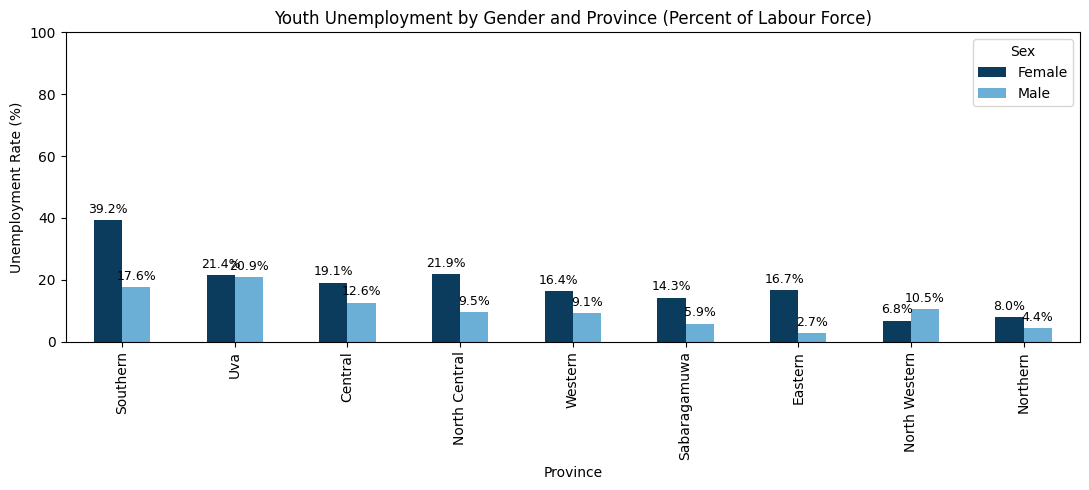

In [448]:
## Province-level graph (ONLY unemployed, 100%)

import matplotlib.pyplot as plt

plot_df = province_gender_unemp.reset_index().pivot(
    index='PROVINCE',
    columns='SEX',
    values='Unemployed'
)

# preserve descending order
plot_df = plot_df.loc[province_order]

dark_blue = '#0B3C5D'   # Female
light_blue = '#6BAED6'  # Male

ax = plot_df.plot(
    kind='bar',
    figsize=(11, 5),
    color=[dark_blue, light_blue]
)

ax.set_ylabel("Unemployment Rate (%)")
ax.set_xlabel("Province")
ax.set_title("Youth Unemployment by Gender and Province (Percent of Labour Force)")
ax.set_ylim(0, 100)
ax.legend(title='Sex')

# percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

In [449]:
#To check Chi-square assumptions for provinces

from scipy.stats import chi2_contingency

for province in df_lf['PROVINCE'].unique():
    subset = df_lf[df_lf['PROVINCE'] == province]
    table = pd.crosstab(subset['SEX'], subset['employment_status'])

    if table.shape != (2, 2):
        print(f"{province}: skipped (incomplete table)")
        continue

    chi2, p_value, dof, expected = chi2_contingency(table)
    min_expected = expected.min()

    if min_expected < 5:
        print(f"{province}: ⚠ min expected = {min_expected:.2f} (assumption violated)")
    else:
        print(f"{province}: ✓ min expected = {min_expected:.2f}")

Western: ✓ min expected = 16.90
Central: ✓ min expected = 14.03
Southern: ✓ min expected = 19.17
Northern: ⚠ min expected = 2.67 (assumption violated)
Eastern: ⚠ min expected = 2.04 (assumption violated)
North Western: ⚠ min expected = 4.06 (assumption violated)
North Central: ⚠ min expected = 4.38 (assumption violated)
Uva: ✓ min expected = 5.92
Sabaragamuwa: ⚠ min expected = 4.61 (assumption violated)


In [450]:
## Chi-square tests
from scipy.stats import chi2_contingency

print("Chi-square Tests: Gender × Province")
print("-" * 45)

for province in df_lf['PROVINCE'].unique():
    subset = df_lf[df_lf['PROVINCE'] == province]
    table = pd.crosstab(subset['SEX'], subset['employment_status'])

    # ensure valid 2x2 table
    if table.shape != (2, 2):
        print(f"{province}: skipped (incomplete table)")
        continue

    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"Province: {province}")
    print("Chi-square statistic =", round(chi2, 2))
    print("Degrees of freedom =", dof)
    print("p-value =", round(p_value, 4))
    print("-" * 45)

Chi-square Tests: Gender × Province
---------------------------------------------
Province: Western
Chi-square statistic = 3.54
Degrees of freedom = 1
p-value = 0.0601
---------------------------------------------
Province: Central
Chi-square statistic = 1.0
Degrees of freedom = 1
p-value = 0.3168
---------------------------------------------
Province: Southern
Chi-square statistic = 9.94
Degrees of freedom = 1
p-value = 0.0016
---------------------------------------------
Province: Northern
Chi-square statistic = 0.37
Degrees of freedom = 1
p-value = 0.544
---------------------------------------------
Province: Eastern
Chi-square statistic = 4.5
Degrees of freedom = 1
p-value = 0.0339
---------------------------------------------
Province: North Western
Chi-square statistic = 0.13
Degrees of freedom = 1
p-value = 0.7192
---------------------------------------------
Province: North Central
Chi-square statistic = 1.79
Degrees of freedom = 1
p-value = 0.1803
-----------------------------

**Objective 4**

**Modelling Factors Associated with Youth Unemployment**

Preparing the Modelling Dataset

In [451]:
#Create binary response variable
df_lf['unemployed'] = df_lf['employment_status'].map({
    'Employed': 0,
    'Unemployed': 1
})

In [452]:
df_lf['unemployed'].value_counts()

unemployed
0.0    1239
1.0     189
Name: count, dtype: int64

In [453]:
#Selecting predictor variables
predictor_vars = [
    'AGE',
    'SEX',
    'EDU_group',
    'SECTOR',
    'PROVINCE',
    'P21'
]

X = df_lf[predictor_vars]
y = df_lf['unemployed']

In [454]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 1 to 18900
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AGE        1428 non-null   int64   
 1   SEX        1428 non-null   category
 2   EDU_group  1428 non-null   object  
 3   SECTOR     1428 non-null   category
 4   PROVINCE   1428 non-null   object  
 5   P21        1428 non-null   category
dtypes: category(3), int64(1), object(2)
memory usage: 49.2+ KB


Encoding Categorical Variables

In [455]:
#Create dummy variables
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)
#drop_first=True sets reference categories

In [456]:
X_encoded.head()

,AGE,SEX_Male,EDU_group_G.C.E.(A/L),EDU_group_G.C.E.(O/L),EDU_group_Grade 5 or Below,EDU_group_Grade 6-10,SECTOR_Rural,SECTOR_Urban,PROVINCE_Eastern,PROVINCE_North Central,PROVINCE_North Western,PROVINCE_Northern,PROVINCE_Sabaragamuwa,PROVINCE_Southern,PROVINCE_Uva,PROVINCE_Western,P21_Not studying
1,29,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,True
15,23,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
20,20,True,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True
29,27,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,True
48,26,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True,True


Fitting Logistic Regression Models

In [457]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [458]:
#Train–test split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42
)

# 70% → training data
# 30% → testing data
# random_state ensures reproducibility

Baseline Logistic Regression (no class weights)

In [459]:
# Fit logistic regression model

log_model_base = LogisticRegression(max_iter=1000)
log_model_base.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Weighted Logistic Regression (handle class imbalance)

In [460]:
log_model_weighted = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_weighted.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [461]:
log_model_base, log_model_weighted

(LogisticRegression(max_iter=1000),
 LogisticRegression(class_weight='balanced', max_iter=1000))

Model Evaluation and Comparison

In [462]:
# Predict employment status

y_pred_base = log_model_base.predict(X_test)
y_pred_weighted = log_model_weighted.predict(X_test)

In [463]:
# Accuracy score

from sklearn.metrics import accuracy_score

acc_base = accuracy_score(y_test, y_pred_base)
acc_weighted = accuracy_score(y_test, y_pred_weighted)

acc_base, acc_weighted

(0.8554778554778555, 0.627039627039627)

In [464]:
print(f"Baseline model accuracy: {acc_base:.4f}")
print(f"Weighted model accuracy: {acc_weighted:.4f}")

Baseline model accuracy: 0.8555
Weighted model accuracy: 0.6270


Baseline accuracy is usually higher Weighted accuracy may drop slightly

In [465]:
# Classification report

# Baseline Model Report
from sklearn.metrics import classification_report

print("Baseline Logistic Regression")
print(classification_report(y_test, y_pred_base))

Baseline Logistic Regression
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       370
         1.0       0.00      0.00      0.00        59

    accuracy                           0.86       429
   macro avg       0.43      0.50      0.46       429
weighted avg       0.74      0.86      0.80       429



In [466]:
# Weighted Model Report
print("Weighted Logistic Regression")
print(classification_report(y_test, y_pred_weighted))

Weighted Logistic Regression
              precision    recall  f1-score   support

         0.0       0.93      0.62      0.74       370
         1.0       0.22      0.69      0.34        59

    accuracy                           0.63       429
   macro avg       0.58      0.66      0.54       429
weighted avg       0.83      0.63      0.69       429



The weighted model is better at identifying unemployed youth.

In [467]:
# Confusion matrix for baseline model
from sklearn.metrics import confusion_matrix

cm_base = confusion_matrix(y_test, y_pred_base)
cm_base

array([[367,   3],
       [ 59,   0]])

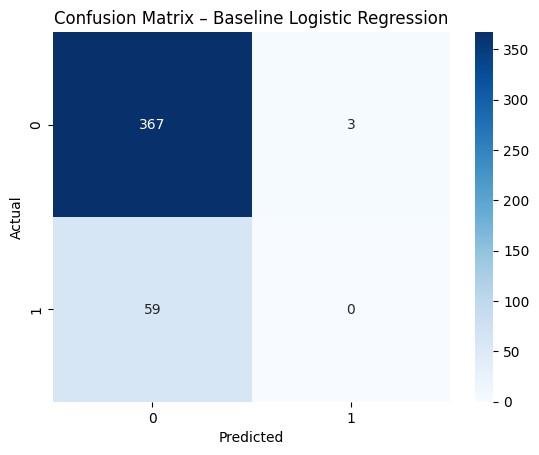

In [468]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Baseline Logistic Regression")
plt.show()

In [469]:
# Confusion matrix for weighted model
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
cm_weighted

array([[228, 142],
       [ 18,  41]])

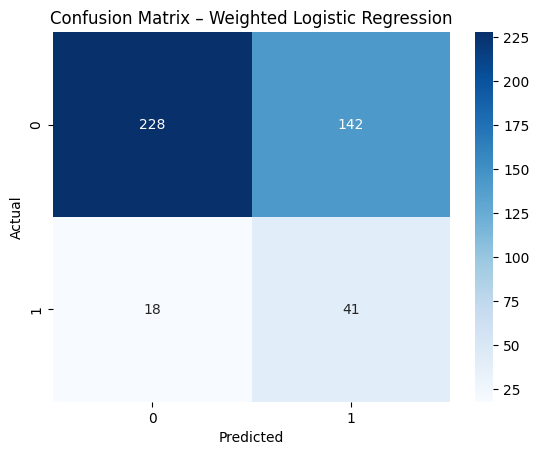

In [470]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Weighted Logistic Regression")
plt.show()

Interpretation of the Weighted Logistic Regression Model

In [471]:
# Create coefficient table
coef_table = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Coefficient': log_model_weighted.coef_[0]
})

# Custom ordering by variable type
order = (
    coef_table['Variable'].str.contains('PROVINCE').map({True: 1, False: 0}) +
    coef_table['Variable'].str.contains('SECTOR').map({True: 2, False: 0}) +
    coef_table['Variable'].str.contains('EDU').map({True: 3, False: 0}) +
    coef_table['Variable'].str.contains('SEX').map({True: 4, False: 0}) +
    coef_table['Variable'].str.contains('AGE').map({True: 5, False: 0})
)

coef_table['Order'] = order

coef_table = coef_table.sort_values(
    by=['Order', 'Coefficient'],
    ascending=[True, False]
).drop(columns='Order')

coef_table

,Variable,Coefficient
16,P21_Not studying,-0.499388
13,PROVINCE_Southern,0.898835
14,PROVINCE_Uva,0.540064
9,PROVINCE_North Central,-0.021922
15,PROVINCE_Western,-0.153975
12,PROVINCE_Sabaragamuwa,-0.545471
8,PROVINCE_Eastern,-0.628769
10,PROVINCE_North Western,-0.638001
11,PROVINCE_Northern,-1.396793
6,SECTOR_Rural,-0.228195
